## Synthetic example for the MESA paper.
#### Objective: Showcase the effects of changes in the different STFT parameters. 

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy

### Build the signal

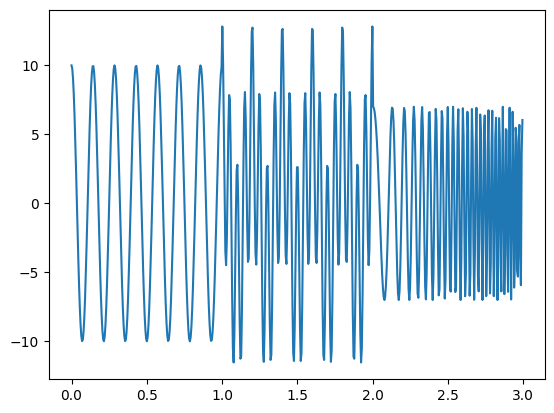

In [16]:
sr = 200 # Hz
duration = 3.0 # s
N = int(sr*duration)
x = np.linspace(0, duration, N)

y1 = 10*np.cos(2*np.pi*7.0*x[0:N//3]) # Mono-mode signal
y2 = 5*np.cos(2*np.pi*5.0*x[N//3:N//3*2]) + 8*np.cos(2*np.pi*20.0*x[N//3:N//3*2]) # Bi-modal signal
y3 = 7*scipy.signal.chirp(x[0:N//3], f0=5.0, t1=duration//3, f1=50.0)

y = np.append(y1, y2, axis = 0)
y = np.append(y,  y3, axis = 0)

plt.plot(x[0:-1], y[0:-1])


In [21]:
window_length = int(.05*sr)
hop = window_length//1
window = "blackman"
n_bins = window_length
window_length

10

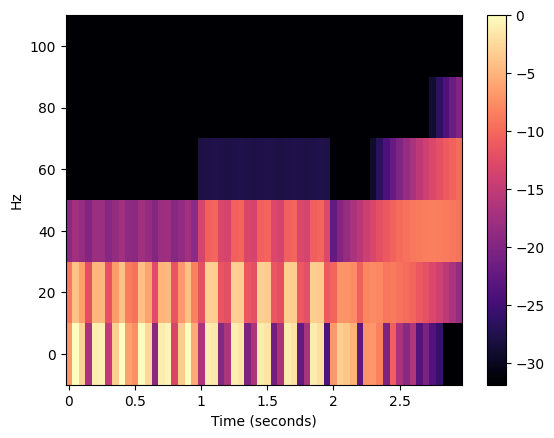

In [23]:
D = librosa.stft(y, n_fft=n_bins, hop_length=hop, win_length=window_length, window=window, center=False)
D.shape
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max, amin = 1)
fig, ax = plt.subplots()
img = librosa.display.specshow(S_db, sr = sr, hop_length=hop, win_length=window_length,
                               x_axis='s', y_axis='linear', 
                            #    cmap = 'nipy_spectral',
                               ax=ax)
fig.colorbar(img, ax=ax)